# Planning Plots

In [202]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
from simulation.trajectory_sampler import *
from envs import *
from policies import *
from data_processors import *
from scipy.stats import sem, t
import os


# font = {'size'   : 13}
# plt.rc('font', **font)  # pass in the font dict as kwargs

# GAPS
font = {'size'   : 20}
plt.rc('font', **font)  # pass in the font dict as kwargs



In [2]:
# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

# RESULTS

In [189]:
# Path principali per i risultati
paths = [
    # "/Users/gianmarcotedeschi/Projects/learnRL/results_swingup/_03_21-12_17_PG_300_ns_cartpole_2_500_10_adam_0005_100_noclip_force_10.0_mu_p_0.0__deep_gaussian_1475_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results_swingup/_03_21-12_17_PG_300_ns_cartpole_2_500_10_adam_0005_100_noclip_force_10.0_mu_p_0.01__deep_gaussian_1475_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results_swingup/_03_21-12_17_PG_300_ns_cartpole_2_500_10_adam_0005_100_noclip_force_10.0_mu_p_0.001__deep_gaussian_1475_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results_swingup/_03_21-12_17_PG_300_ns_cartpole_2_500_10_adam_0005_100_noclip_force_10.0_mu_p_0.03__deep_gaussian_1475_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results_swingup/_03_21-14_41_PG_300_ns_cartpole_2_1000_10_adam_0005_100_noclip_force_10.0_mu_p_0.01__deep_gaussian_1475_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results_swingup/_03_21-14_41_PG_300_ns_cartpole_2_1000_10_adam_0005_100_noclip_force_10.0_mu_p_0.001__deep_gaussian_1475_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results_swingup/_03_24-15_24_PG_300_ns_cartpole_2_1000_10_adam_0005_100_noclip_force_10.0_mu_p_0.01__deep_gaussian_1475_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results/half_cheetah",
]

# Labels per i trial
lab = [
    "mu_p=0.0",
    "mu_p=0.01",
    "mu_p=0.001",
    "mu_p=0.03",
    "mu_p=0.04",
    "mu_p=0.05",
    "mu_p=0.0008",
]

In [190]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

In [161]:
print(all_performances)

[array([[ 2.74164525,  6.05072571, 15.60724568, ...,  0.        ,
         0.        ,  0.        ],
       [ 6.88160978, 11.43178918, 14.60079811, ...,  0.        ,
         0.        ,  0.        ],
       [18.40194734, 21.83437587, 24.92505672, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [12.80689608,  5.65182139,  8.84279412, ...,  0.        ,
         0.        ,  0.        ],
       [11.40469735, 10.47931493, 10.55715873, ...,  0.        ,
         0.        ,  0.        ],
       [13.47631924, 15.9468091 , 19.87254094, ...,  0.        ,
         0.        ,  0.        ]])]


<Figure size 640x480 with 0 Axes>

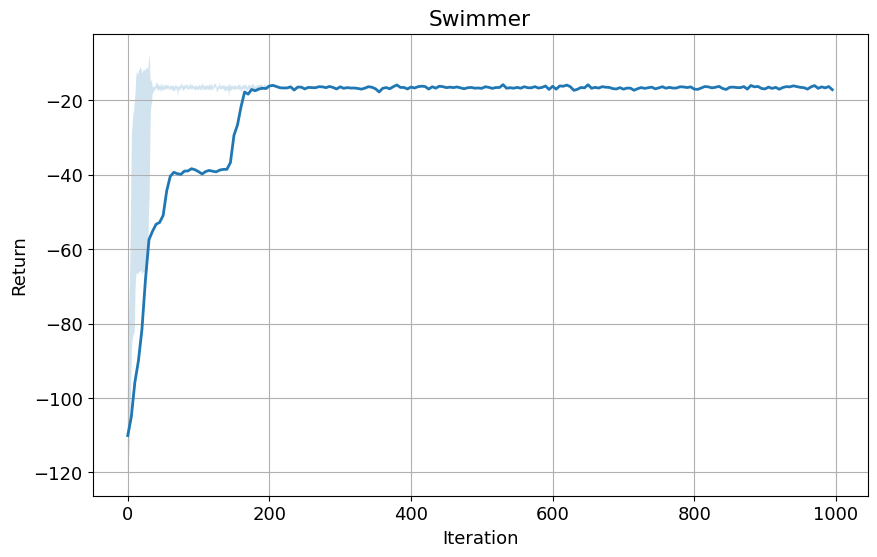

In [ ]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label=lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        # print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Swimmer")
plt.xlabel("Iteration")
plt.ylabel("Return")

# plt.legend(loc="best")
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

# GAPS MLJ REDO

In [266]:
paths = [
    # GAPS
    # "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_05_20-21_45_split_1000_swimmer_200_constant_0001_split_gaussian_batch_100_clip_2_std_01_alpha_01", 
    "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-14_24_agaps_1000_lq_10_constant_0001_split_gaussian_batch_100_clip_1_std_01_alpha_01",
    # "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-16_51_agaps_1000_minigolf_200_constant_001_split_gaussian_batch_100_clip_1_std_01_alpha_01",
    # "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/_12_12-18_54_agaps_1000_half_cheetah_100_adam_0001_split_gaussian_batch_200_clip_6_std_01_alpha_01",
    
    # RBF
    # "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_11-20_47_pg_1000_half_cheetah_100_adam_0001_gaussian_batch_100_clip_102_std_01_alpha_01", 
    # "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_11-20_47_pg_1000_swimmer_200_adam_0001_gaussian_batch_100_clip_16_std_01_alpha_01",
    "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-14_29_pg_1000_lq_10_adam_0001_gaussian_batch_100_clip_1_std_01_alpha_01",
    # "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-15_01_pg_1000_minigolf_200_adam_0001_gaussian_batch_100_clip_1_std_01_alpha_01",

    # MLP
    # "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-19_50_pg_1000_half_cheetah_100_adam_0001_deep_gaussian_batch_100_clip_624_std_01_alpha_01", 
    # "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-19_21_pg_1000_minigolf_200_adam_0001_deep_gaussian_batch_100_clip_288_std_01_alpha_01",
    # "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-17_57_pg_1000_swimmer_200_adam_0001_deep_gaussian_batch_100_clip_416_std_1_alpha_01",
    "/Users/gianmarcotedeschi/Desktop/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-17_43_pg_1000_lq_10_adam_0001_deep_gaussian_batch_100_clip_288_std_01_alpha_01",
 
    # NEAT
    # "/Users/gianmarcotedeschi/Projects/learnRL/results/swimmer/04_11-19_00/H_200_g_0995",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results/minigolf/04_11-18_59/H_200_g_0995",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results/lq/04_11-18_59/H_10_g_09"
    # "/Users/gianmarcotedeschi/Projects/learnRL/results/lq/04_15-16_46/H_10_g_09"
    # "/Users/gianmarcotedeschi/Projects/learnRL/results/lq/04_16-17_57/H_10_g_09",
    "/Users/gianmarcotedeschi/Projects/learnRL/results/lq/04_16-18_05/H_10_g_09",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results/half_cheetah/04_11-19_00/H_100_g_0995"
]


lab = [
    "GAPS",
    "PG-RBF",
    "PG-MLP",
    "NEAT",
]

In [234]:
import os
import json
import numpy as np

# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            for filename in ["results.json", "pg_results.json"]:
                file_path = os.path.join(trial_path, filename)
                if os.path.isfile(file_path):
                    try:
                        with open(file_path, 'r') as file:
                            data = json.load(file)
                            trial_performances.append(data["performance"])
                        break  # Se ha trovato e letto correttamente un file, esce dal ciclo interno
                    except (json.JSONDecodeError, KeyError) as e:
                        print(f"Errore nel leggere {file_path}: {e}")
                        break  # Se il file esiste ma è malformato, non provare l'altro
    return np.array(trial_performances)  # Converte in array per calcoli successivi


In [267]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

-15.312614703128279
-16.235219354939698
-14.390010051316862
-16.89918969862152
-17.77203915132592
-16.026340245917115
-13.902602126522515
-14.683994314384378
-13.121209938660654
-14.839075731067647
-15.633106565620178
-14.045044896515115


<Figure size 640x480 with 0 Axes>

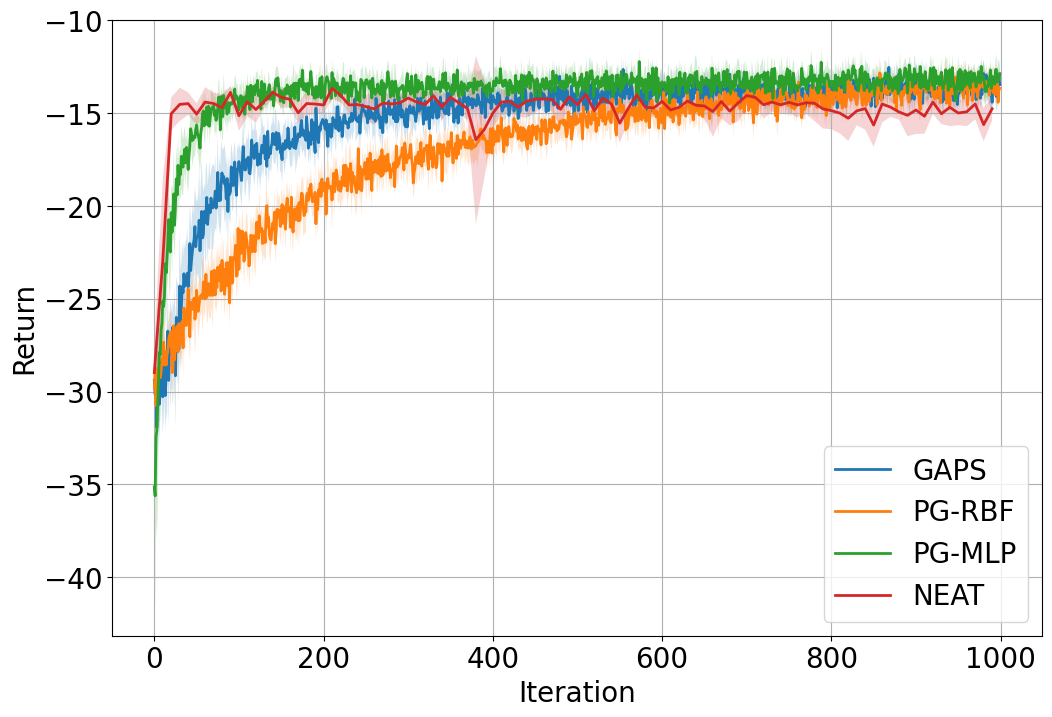

In [271]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(12, 8))
max_length = max(perf.shape[1] for perf in all_performances if perf.size > 0)

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)
        
        length = len(mean_performance)

        # Asse x: se il numero di punti è minore del massimo, scala l'asse
        if length < max_length:
            step = max_length // length
            x_vals = np.arange(0, max_length, step)
            # In caso di divisione imperfetta, taglia l'array per sicurezza
            mean_performance = mean_performance[:len(x_vals)]
            std_performance = std_performance[:len(x_vals)]
        else:
            x_vals = np.arange(length)

        # Plot della curva media
        plt.plot(x_vals, mean_performance, linewidth=2, label=lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            x_vals,
            lower,
            higher,
            alpha=0.2
        )

        print(np.mean(mean_performance))
        print(np.mean(lower))
        print(np.mean(higher))

# Etichette e titolo
# plt.title("Swimmer")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend(loc="best")
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("lq_gaps_final.pdf", format='pdf')
plt.show()
